<a href="https://colab.research.google.com/github/July230/AviDetect/blob/develop/AviDetectPredict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerías

In [1]:
import os
import json
import io
import random
from PIL import Image
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# Función para consultar el modelo entrenado

In [2]:
# Create a new model with the saved weights
def getModel(modelPath):
  model = tf.keras.models.load_model(modelPath)
  return model

# Función para crear la arquitectura del primer modelo

In [3]:
def getModelCompiled():
  """
  Creates the model and compiles it

  Parameters
  ----------
  None

  Returns
  -------
  model : keras.models.Sequential
    Compiled model
  """
  model = tf.keras.models.Sequential()
  model.add(tf.keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape = (224,224,3)))
  model.add(tf.keras.layers.MaxPooling2D((2, 2)))
  model.add(tf.keras.layers.Conv2D(64, (3, 3), activation="relu", input_shape = (224,224,3)))
  model.add(tf.keras.layers.MaxPooling2D((2, 2)))
  model.add(tf.keras.layers.Conv2D(128, (3, 3), activation="relu", input_shape = (224,224,3)))
  model.add(tf.keras.layers.MaxPooling2D((2, 2)))
  model.add(tf.keras.layers.Flatten())
  model.add(tf.keras.layers.Dense(128,activation="relu"))
  model.add(tf.keras.layers.Dense(1,activation="sigmoid"))

  model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"])

  return model

# Funciones para subir una imagen

In [4]:
def uploadImage(uploadDirectory = "infer"):
  """
  Uploads an image, saves it to the specified directory, and
  returns the path to the saved image.

  Parameters
  ----------
  uploadDirectory : str
    The directory where the image will be saved

  Returns
  -------
  filepath : str
    The path to the saved image
  """
  os.makedirs(uploadDirectory, exist_ok=True)
  uploaded = files.upload()
  filename = next(iter(uploaded))
  filepath = os.path.join(uploadDirectory, filename)

  image = Image.open(io.BytesIO(uploaded[filename]))

  with open(filepath, "wb") as f:
      f.write(uploaded[filename])

  print(f"Image saved in: {filepath}")

  return filepath

def proprocessImage(imagePath):
  """
  Preprocesses an image by resizing it to 224x224 pixels,
  converting it to a numpy array, normalizing its pixel values and
  adding an extra dimension.

  Parameters
  ----------
  imagePath : str
    The path to the image file

  Returns
  -------
  image : numpy.ndarray
    The preprocessed image
  """
  image = Image.open(imagePath).convert("RGB")
  image = image.resize((224, 224))
  image = np.array(image)
  image = image / 255.0
  image = np.expand_dims(image, axis=0)
  return image

In [5]:
def predictSingleImage(model, imagePath):
  """
  Predicts the class of an image using a trained model.

  Parameters
  ----------
  model : tf.keras.Model
    The trained model
  imagePath : str
    The path to the image file

  Returns
  -------
  predictedClass : str
    The predicted class of the image
  probability : float
    The probability of the predicted class
  """
  image = proprocessImage(imagePath)

  probability = model.predict(image, verbose=0)[0][0]

  if probability > 0.5:
    predictedClass = "drone"
  else:
    predictedClass = "bird"

  return predictedClass, probability

def displayPrediction(imagePath, predictedClass, probability):
    """
    Displays the image and prediction probabilities.

    Parameters
    ----------
    imagePath : str
        Path to the image.
    predictedClass : str
        Predicted class.
    probability : float
        Probability of drone class.
    """

    birdProbability = 1 - probability
    droneProbability = probability

    image = Image.open(imagePath)

    plt.figure(figsize=(12, 3))

    # Imagen
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Your prediction: {predictedClass}")

    # Probabilidades
    plt.subplot(1, 2, 2)
    plt.bar(
        ["Bird", "Drone"],
        [birdProbability * 500, droneProbability * 500]
    )
    plt.ylabel("Probability (%)")
    plt.ylim(0, 500)
    plt.title("Model confidence")

    plt.show()

def predictDirectory(model, directory):
  """
  Predicts the class of all images in a directory using a trained model.

  Parameters
  ----------
  model : tf.keras.Model
    The trained model
  directory : str
    The path to the directory containing the images

  Returns
  -------
  None
  """
  validExtensions = (".png", ".jpg", ".jpeg")

  for filename in os.listdir(directory):
    if not filename.lower().endswith(validExtensions):
      continue

    imagePath = os.path.join(directory, filename)
    predictedClass, probability = predictSingleImage(model, imagePath)

    print(f"Image: {filename}")
    print(f"Predicted class: {predictedClass}")
    print(f"Drone probability: {probability*100:.2f}%")
    print(f"Bird probability: {(1-probability)*100:.2f}%")
    print("-"*40)

    displayPrediction(imagePath, predictedClass, probability)

In [6]:
def predictRandom(model, directory, numImages = 1):
  """
  Predicts the class of a random image in a directory using a trained model.

  Parameters
  ----------
  model : tf.keras.Model
    The trained model
  directory : str
    The path to the directory containing the images
  numImages : int
    The number of images to predict

  Returns
  -------
  None
  """

  validExtensions = (".png", ".jpg", ".jpeg")

  images = [image for image in os.listdir(directory) if image.lower().endswith(validExtensions)]

  if not images:
    print("No images found in the directory.")
    return

  for _ in range(numImages):
    randomImage = random.choice(images)
    imagePath = os.path.join(directory, randomImage)
    predictedClass, probability = predictSingleImage(model, imagePath)

    print(f"Image: {imagePath}")
    print(f"Predicted class: {predictedClass}")
    print(f"Drone probability: {probability*100:.2f}%")
    print(f"Bird probability: {(1-probability)*100:.2f}%")
    print("-"*40)

    displayPrediction(imagePath, predictedClass, probability)

In [7]:
def predictSelectedImage(model, directory):
  """
  Allows the user to select an image from a directory and predicts its class using a trained model.

  Parameters
  ----------
  model : tf.keras.Model
    The trained model
  directory : str
    The path to the directory containing the images

  Returns
  -------
  None
  """

  validExtensions = (".png", ".jpg", ".jpeg")

  images = sorted([
      file for file in os.listdir(directory)
      if file.lower().endswith(validExtensions)
  ])

  if not images:
    print("No images found in the directory.")
    return

  print("Available images:\n")

  for index, image in enumerate(images, start=1):
    print(f"{index}. {image}")

  filename = input("\nEnter the image name exactly as shown: ")

  if filename not in images:
    print("Image not found.")
    return

  imagePath = os.path.join(directory, filename)
  predictedClass, probability = predictSingleImage(model, imagePath)

  print(f"Image: {filename}")
  print(f"Predicted class: {predictedClass}")
  print(f"Drone probability: {probability*100:.2f}%")
  print(f"Bird probability: {(1-probability)*100:.2f}%")
  print("-"*40)

  displayPrediction(imagePath, predictedClass, probability)

In [8]:
parentDirectory = "/content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual"

In [9]:
%cd {parentDirectory}

/content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual


In [10]:
%ls

 aguila-real.jpg
'Ara chloroptera 2.jpg'
 aves-1_0931d689_221212154441_1280x720.jpg
 aves-de-rapiña-presa-rapaces-depredador-tipos-buho-e1561932282180.jpg
 AviDetectClassifier.ipynb
 AviDetectPredict.ipynb
 BirdVSDrone/
 checkpoints/
 infer/
 Mejores-Drones-con-Camara.png
 Protonotaria-citrea-002_edit.jpg


In [11]:
!mkdir "infer"

mkdir: cannot create directory ‘infer’: File exists


In [12]:
%ls

 aguila-real.jpg
'Ara chloroptera 2.jpg'
 aves-1_0931d689_221212154441_1280x720.jpg
 aves-de-rapiña-presa-rapaces-depredador-tipos-buho-e1561932282180.jpg
 AviDetectClassifier.ipynb
 AviDetectPredict.ipynb
 BirdVSDrone/
 checkpoints/
 infer/
 Mejores-Drones-con-Camara.png
 Protonotaria-citrea-002_edit.jpg


# Importar los modelos

In [13]:
inferDirectory = os.path.join(parentDirectory, "infer")

In [14]:
firstModelPath = "checkpoints/ThreeLayerCNN/checkpoint.weights.h5"
FirstAviDetect = getModelCompiled()
FirstAviDetect.load_weights(firstModelPath)
FirstAviDetect.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
modelPath = "checkpoints/ThreeLayerCNNTunned/ThreeLayerCNNTunned.keras"
AviDetect = getModel(modelPath)
AviDetect.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,507,269 (127.82 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,180 (85.21 MB)

# Subir una imagen

In [55]:
uploadImage(inferDirectory)

Saving Ara chloroptera 2.jpg to Ara chloroptera 2.jpg
Image saved in: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/infer/Ara chloroptera 2.jpg


'/content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/infer/Ara chloroptera 2.jpg'

## Predicciones del primer modelo

Image: Autumn_Drone_(cropped).jpg
Predicted class: drone
Drone probability: 63.61%
Bird probability: 36.39%
----------------------------------------


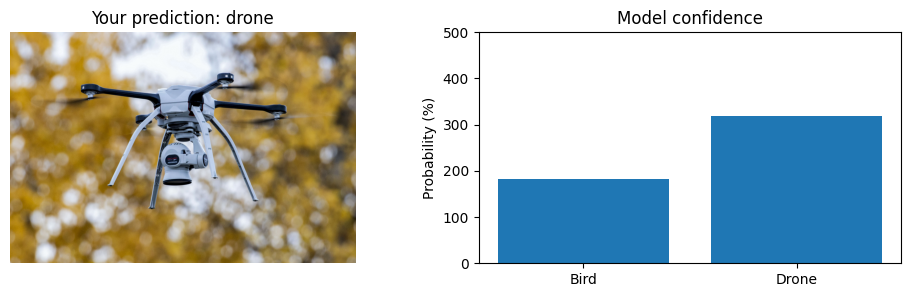

Image: Mejores-Drones-con-Camara.png
Predicted class: bird
Drone probability: 42.17%
Bird probability: 57.83%
----------------------------------------


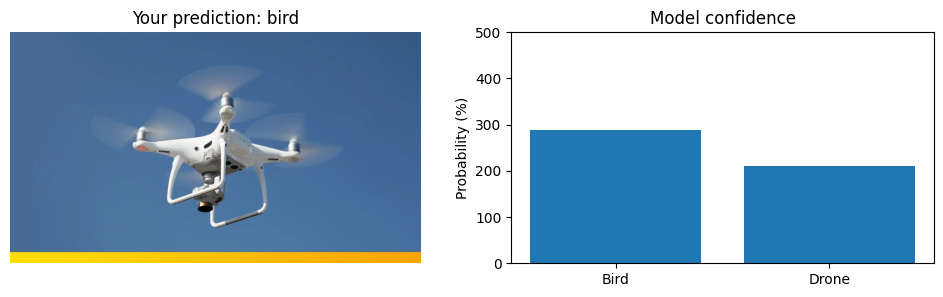

Image: Protonotaria-citrea-002_edit.jpg
Predicted class: drone
Drone probability: 76.28%
Bird probability: 23.72%
----------------------------------------


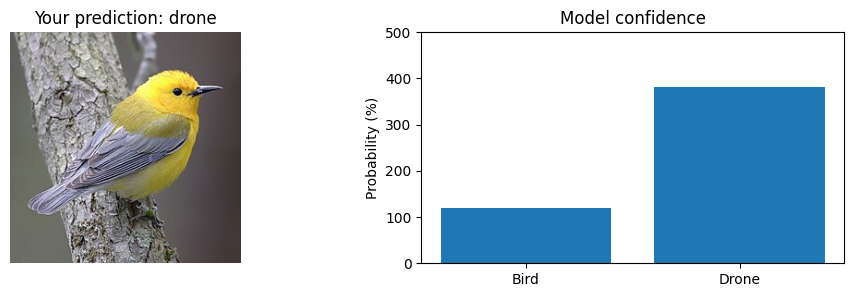

Image: aves-1_0931d689_221212154441_1280x720.jpg
Predicted class: bird
Drone probability: 0.13%
Bird probability: 99.87%
----------------------------------------


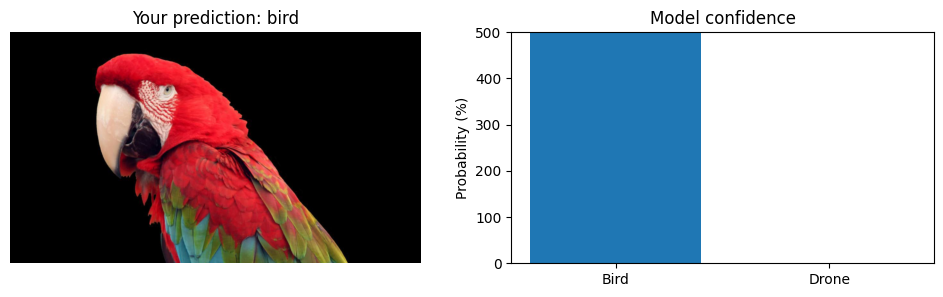

Image: aves-de-rapiña-presa-rapaces-depredador-tipos-buho-e1561932282180.jpg
Predicted class: drone
Drone probability: 68.27%
Bird probability: 31.73%
----------------------------------------


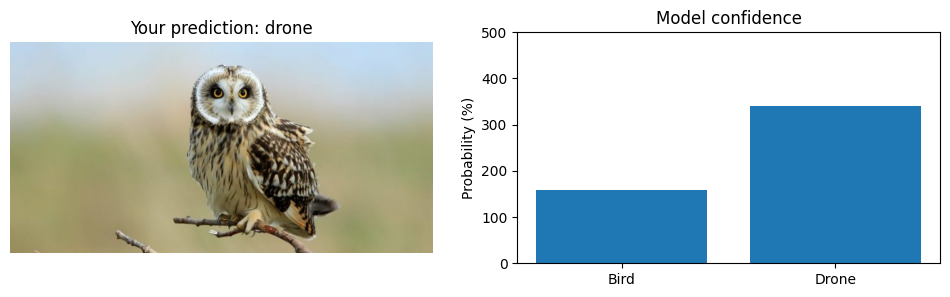

Image: aguila-real.jpg
Predicted class: drone
Drone probability: 86.27%
Bird probability: 13.73%
----------------------------------------


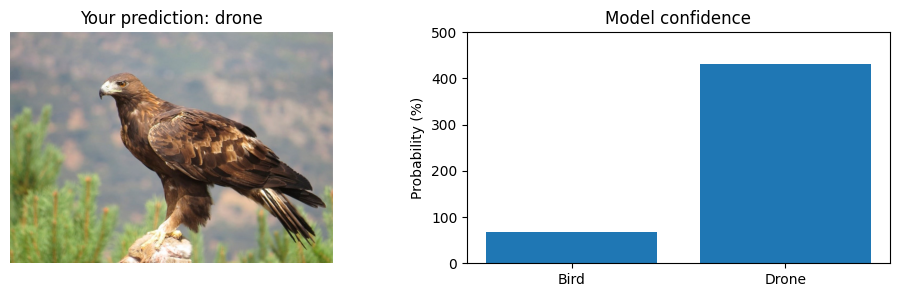

Image: Ara chloroptera 2.jpg
Predicted class: drone
Drone probability: 50.06%
Bird probability: 49.94%
----------------------------------------


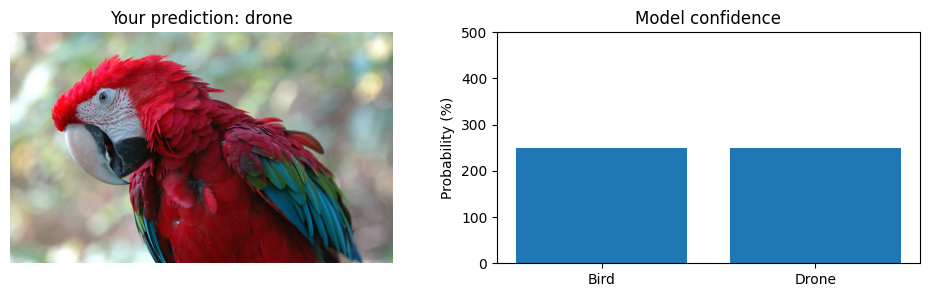

In [30]:
predictDirectory(FirstAviDetect, "infer")

Image: infer/aves-de-rapiña-presa-rapaces-depredador-tipos-buho-e1561932282180.jpg
Predicted class: drone
Drone probability: 68.27%
Bird probability: 31.73%
----------------------------------------


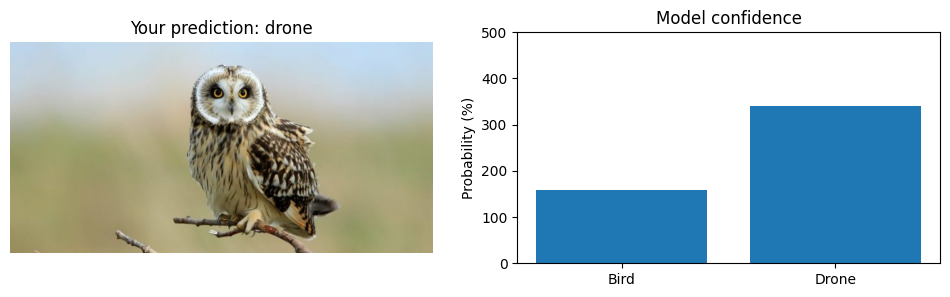

In [31]:
predictRandom(FirstAviDetect, "infer")

Available images:

1. Ara chloroptera 2.jpg
2. Autumn_Drone_(cropped).jpg
3. Mejores-Drones-con-Camara.png
4. Protonotaria-citrea-002_edit.jpg
5. aguila-real.jpg
6. aves-1_0931d689_221212154441_1280x720.jpg
7. aves-de-rapiña-presa-rapaces-depredador-tipos-buho-e1561932282180.jpg

Enter the image name exactly as shown: Protonotaria-citrea-002_edit.jpg
Image: Protonotaria-citrea-002_edit.jpg
Predicted class: drone
Drone probability: 76.28%
Bird probability: 23.72%
----------------------------------------


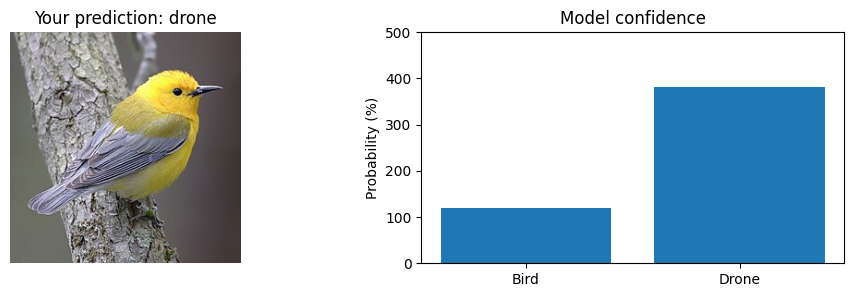

In [29]:
predictSelectedImage(FirstAviDetect, "infer")

## Predicciones del segundo modelo

Image: Autumn_Drone_(cropped).jpg
Predicted class: bird
Drone probability: 43.87%
Bird probability: 56.13%
----------------------------------------


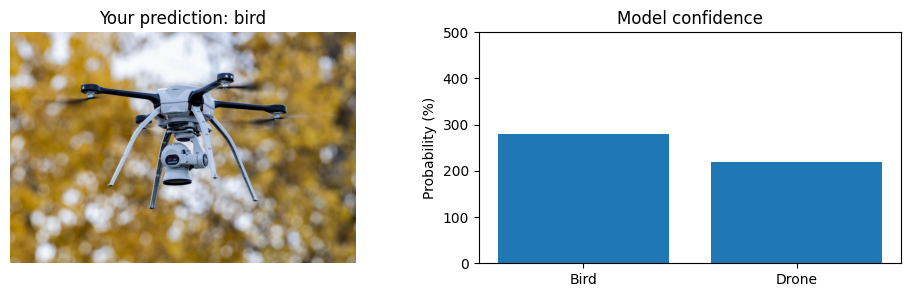

Image: Mejores-Drones-con-Camara.png
Predicted class: drone
Drone probability: 62.93%
Bird probability: 37.07%
----------------------------------------


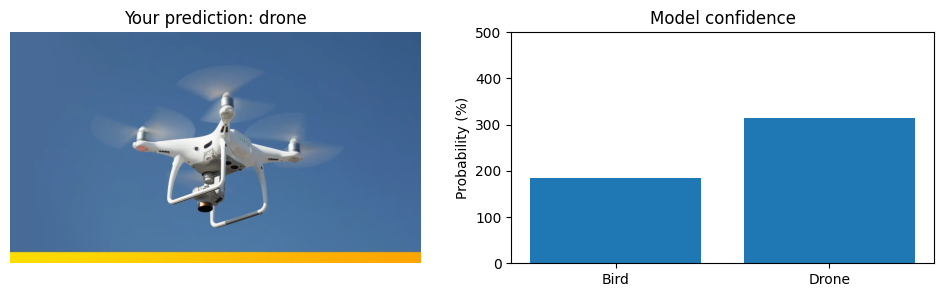

Image: Protonotaria-citrea-002_edit.jpg
Predicted class: bird
Drone probability: 49.91%
Bird probability: 50.09%
----------------------------------------


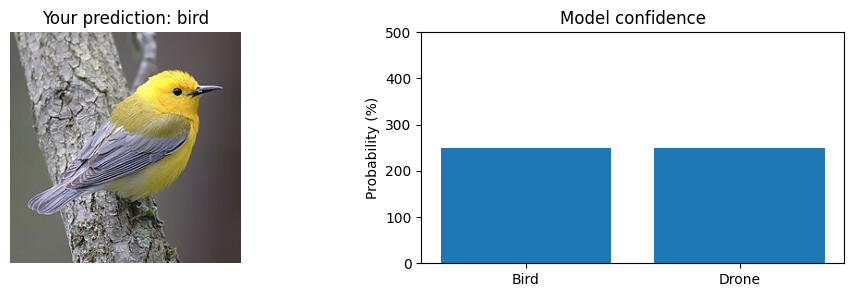

Image: aves-1_0931d689_221212154441_1280x720.jpg
Predicted class: bird
Drone probability: 0.00%
Bird probability: 100.00%
----------------------------------------


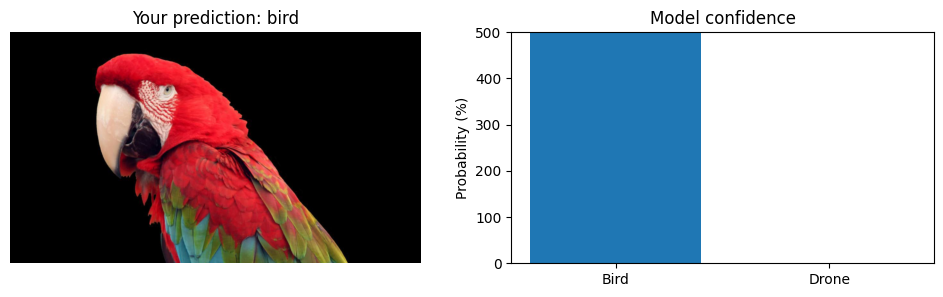

Image: aves-de-rapiña-presa-rapaces-depredador-tipos-buho-e1561932282180.jpg
Predicted class: drone
Drone probability: 54.42%
Bird probability: 45.58%
----------------------------------------


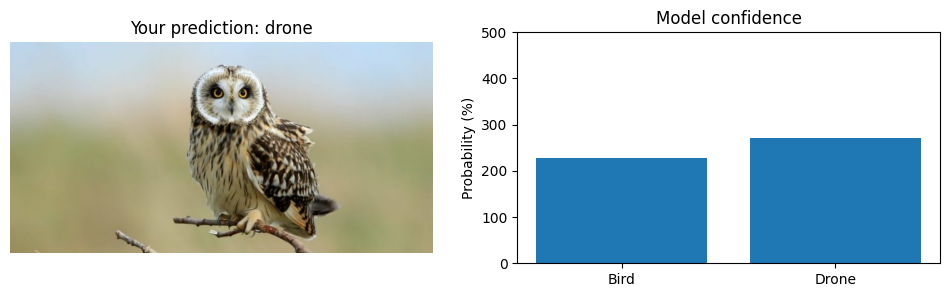

Image: aguila-real.jpg
Predicted class: drone
Drone probability: 75.41%
Bird probability: 24.59%
----------------------------------------


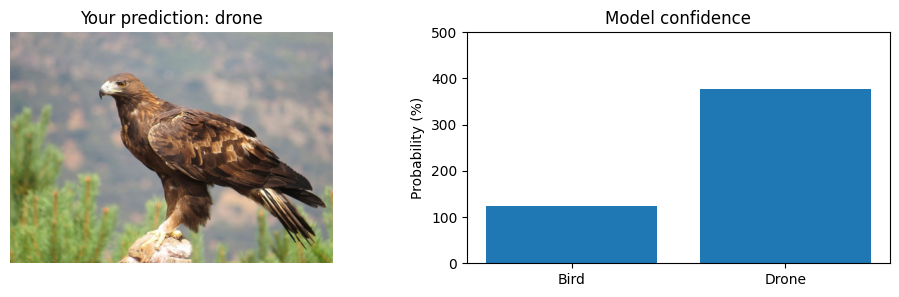

Image: Ara chloroptera 2.jpg
Predicted class: bird
Drone probability: 17.89%
Bird probability: 82.11%
----------------------------------------


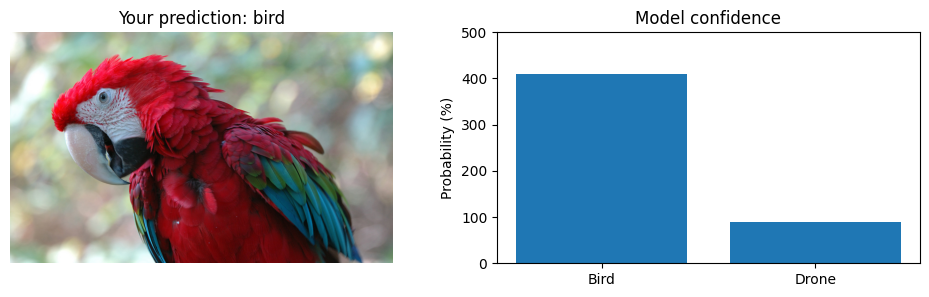

In [25]:
predictDirectory(AviDetect, "infer")

Image: infer/aves-de-rapiña-presa-rapaces-depredador-tipos-buho-e1561932282180.jpg
Predicted class: drone
Drone probability: 54.42%
Bird probability: 45.58%
----------------------------------------


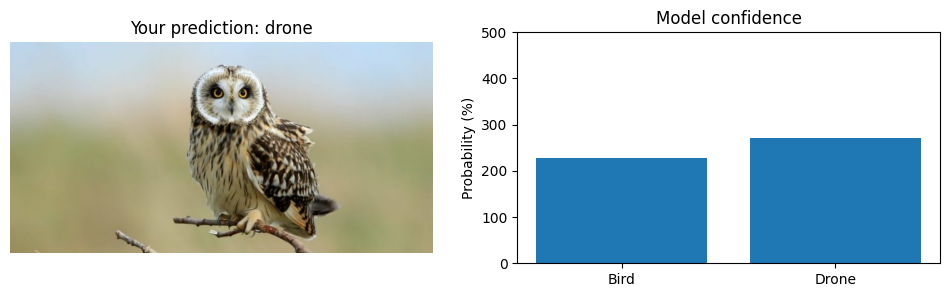

In [33]:
predictRandom(AviDetect, "infer")

Available images:

1. Ara chloroptera 2.jpg
2. Autumn_Drone_(cropped).jpg
3. Mejores-Drones-con-Camara.png
4. Protonotaria-citrea-002_edit.jpg
5. aguila-real.jpg
6. aves-1_0931d689_221212154441_1280x720.jpg
7. aves-de-rapiña-presa-rapaces-depredador-tipos-buho-e1561932282180.jpg

Enter the image name exactly as shown: Protonotaria-citrea-002_edit.jpg
Image: Protonotaria-citrea-002_edit.jpg
Predicted class: bird
Drone probability: 49.91%
Bird probability: 50.09%
----------------------------------------


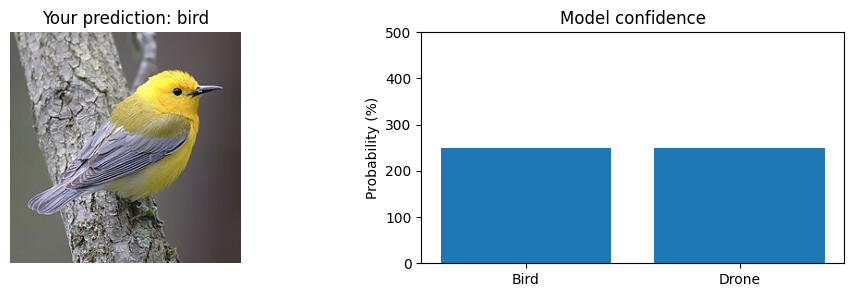

In [34]:
predictSelectedImage(AviDetect, "infer")

# Subir más imagenes

In [16]:
uploadImage(inferDirectory)

Saving Drones_ICA-CSIC.jpg to Drones_ICA-CSIC.jpg
Image saved in: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/infer/Drones_ICA-CSIC.jpg


'/content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/infer/Drones_ICA-CSIC.jpg'

Available images:

1. Ara chloroptera 2.jpg
2. Autumn_Drone_(cropped).jpg
3. Drones_ICA-CSIC.jpg
4. Mejores-Drones-con-Camara.png
5. Protonotaria-citrea-002_edit.jpg
6. aguila-real.jpg
7. aves-1_0931d689_221212154441_1280x720.jpg
8. aves-de-rapiña-presa-rapaces-depredador-tipos-buho-e1561932282180.jpg

Enter the image name exactly as shown: Drones_ICA-CSIC.jpg
Image: Drones_ICA-CSIC.jpg
Predicted class: drone
Drone probability: 99.47%
Bird probability: 0.53%
----------------------------------------


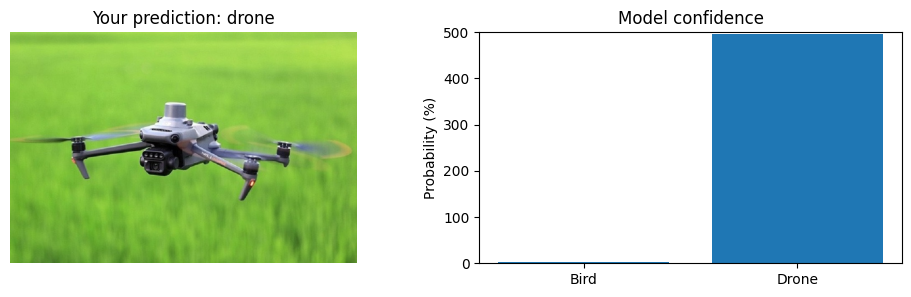

In [18]:
predictSelectedImage(AviDetect, "infer")